# NSMC 감성분석 과제

> 현재 학습 환경의 TrainingArguments에서 group_by_length 옵션을 직접 지원하지 않아, 동일한 목적의 길이 기반 sampler를 사용하는 커스텀 Trainer를 구성하였다. 이를 통해 길이가 비슷한 문장끼리 batch를 구성하고, DataCollatorWithPadding을 함께 사용하여 dynamic padding을 적용함

## GPU 메모리 절약 패치 버전

이 버전은 CUDA OutOfMemoryError 방지를 위해 다음을 적용함

- `MAX_LENGTH = 96`
- `per_device_train_batch_size = 4`
- `per_device_eval_batch_size = 8`
- `gradient_accumulation_steps = 4`
- CUDA 사용 시 `fp16=True`

# NSMC 감성분석 Fine-tuning 과제  
## klue/bert-base 성능 개선 + Bucketing 비교 실험


1. NSMC 데이터 분석 및 Hugging Face Dataset 구성  
2. `klue/bert-base` 모델 및 tokenizer 로드  
3. 기본 fine-tuning baseline 학습  
4. 성능 개선 fine-tuning 적용  
   - 최대 epoch 넉넉하게 설정  
   - validation set 분리  
   - 매 epoch마다 validation loss 확인  
   - best epoch 모델 저장  
   - early stopping  
   - warmup + cosine scheduler  
   - AdamW + gradient clipping  
5. Bucketing + Dynamic Padding 적용  
6. 기존 대비 성능 향상 및 학습 시간 비교  
7. 보고서용 분석 문장 자동 생성

In [11]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

print("torch:", torch.__version__)
import transformers, datasets
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)

torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 4.0.0


## STEP 0-1. 재현성 고정

실험 결과가 매번 크게 달라지지 않도록 seed를 고정

In [12]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [13]:
import gc

def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

clear_gpu_memory()
print("GPU cache cleared")

GPU cache cleared


## STEP 0-2. 실행 모드 설정

처음에는 `FAST_MODE = True`로 실행해서 코드가 정상인지만 확인
최종 결과는 `FAST_MODE = False`로 바꿔 전체 데이터로 학습함

In [14]:
FAST_MODE = False

# 빠른 테스트용 데이터 크기 (FAST_MODE=False일 때는 사용되지 않음)
FAST_TRAIN_SIZE = 3000
FAST_VAL_SIZE = 800
FAST_TEST_SIZE = 800

# 과제 기본 모델
MODEL_NAME = "klue/bert-base"

# NSMC 문장 길이 기준. 128로 상향 조정하여 더 많은 정보를 보존
MAX_LENGTH = 128

print("FAST_MODE:", FAST_MODE)
print("MODEL_NAME:", MODEL_NAME)
print("MAX_LENGTH:", MAX_LENGTH)

FAST_MODE: False
MODEL_NAME: klue/bert-base
MAX_LENGTH: 128


## STEP 1. NSMC 데이터 분석 및 Hugging Face Dataset 구성

In [15]:
nsmc_dataset = load_dataset(
    "csv",
    data_files={
        "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
        "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    },
    delimiter="\t"
)

print(nsmc_dataset)
print("\n첫 번째 샘플:")
print(nsmc_dataset["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})

첫 번째 샘플:
{'id': 9976970, 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}


### STEP 1-1. DataFrame으로 변환 후 데이터 구조 확인

In [16]:
train_df = nsmc_dataset["train"].to_pandas()
test_df = nsmc_dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain columns:", train_df.columns.tolist())
print("\nTrain head:")
display(train_df.head())

Train shape: (150000, 3)
Test shape: (50000, 3)

Train columns: ['id', 'document', 'label']

Train head:


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### STEP 1-2. 결측치, 중복, 라벨 분포 확인


In [17]:
print("[결측치 확인]")
print(train_df.isnull().sum())

print("\n[중복 document 수]")
print("train duplicated:", train_df["document"].duplicated().sum())
print("test duplicated:", test_df["document"].duplicated().sum())

print("\n[라벨 분포]")
print(train_df["label"].value_counts())
print(train_df["label"].value_counts(normalize=True))

[결측치 확인]
id          0
document    5
label       0
dtype: int64

[중복 document 수]
train duplicated: 3817
test duplicated: 842

[라벨 분포]
label
0    75173
1    74827
Name: count, dtype: int64
label
0    0.501153
1    0.498847
Name: proportion, dtype: float64


### STEP 1-3. 문장 길이 확인

In [18]:
train_df["text_len"] = train_df["document"].astype(str).apply(len)
test_df["text_len"] = test_df["document"].astype(str).apply(len)

print("[Train 문장 길이 통계]")
print(train_df["text_len"].describe())

print("\n[Test 문장 길이 통계]")
print(test_df["text_len"].describe())

[Train 문장 길이 통계]
count    150000.000000
mean         35.203487
std          29.531947
min           1.000000
25%          16.000000
50%          27.000000
75%          42.000000
max         146.000000
Name: text_len, dtype: float64

[Test 문장 길이 통계]
count    50000.000000
mean        35.318380
std         29.648413
min          1.000000
25%         16.000000
50%         27.000000
75%         43.000000
max        144.000000
Name: text_len, dtype: float64


### STEP 1-4. 결측치 및 중복 제거

NSMC에는 일부 결측치와 중복 문장이 있을 수 있으므로 제거

In [19]:
clean_train_df = train_df[["document", "label"]].dropna()
clean_test_df = test_df[["document", "label"]].dropna()

before_train = len(clean_train_df)
before_test = len(clean_test_df)

clean_train_df = clean_train_df.drop_duplicates(subset=["document"])
clean_test_df = clean_test_df.drop_duplicates(subset=["document"])

print("Train before:", before_train, "after:", len(clean_train_df))
print("Test before:", before_test, "after:", len(clean_test_df))

Train before: 149995 after: 146182
Test before: 49997 after: 49157


### STEP 1-5. Validation 데이터 분리

과제 요구사항에 맞게 train 데이터에서 validation 데이터를 따로 분리
라벨 비율이 유지되도록 `stratify`를 사용함

In [20]:
from sklearn.model_selection import train_test_split

# 데이터 분리 재실행
train_data, val_data = train_test_split(
    clean_train_df,
    test_size=0.1,
    random_state=42,
    stratify=clean_train_df["label"]
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", clean_test_df.shape)

Train: (131563, 2)
Validation: (14619, 2)
Test: (49157, 2)

Validation label distribution:
label
0    0.501744
1    0.498256
Name: proportion, dtype: float64


### STEP 1-6. Hugging Face DatasetDict 구성

In [21]:
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_data.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_data.reset_index(drop=True)),
    "test": Dataset.from_pandas(clean_test_df.reset_index(drop=True))
})

print(hf_dataset)
print("\n샘플:")
print(hf_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['document', 'label'],
        num_rows: 131563
    })
    validation: Dataset({
        features: ['document', 'label'],
        num_rows: 14619
    })
    test: Dataset({
        features: ['document', 'label'],
        num_rows: 49157
    })
})

샘플:
{'document': '가볍게 보기 좋음. 이지훈 귀여움', 'label': 1}


### STEP 1-7. 빠른 테스트용 Dataset 준비

`FAST_MODE=True`일 때는 일부 데이터만 사용
최종 결과는 전체 데이터로 다시 실행함

In [22]:
from datasets import Dataset, DatasetDict

# DatasetDict 구성
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_data.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_data.reset_index(drop=True)),
    "test": Dataset.from_pandas(clean_test_df.reset_index(drop=True))
})

if not FAST_MODE:
    print(f"Using full dataset for training (Train: {len(hf_dataset['train'])}, Val: {len(hf_dataset['validation'])})")
else:
    hf_dataset = DatasetDict({
        "train": hf_dataset["train"].select(range(min(FAST_TRAIN_SIZE, len(hf_dataset["train"])))),
        "validation": hf_dataset["validation"].select(range(min(FAST_VAL_SIZE, len(hf_dataset["validation"])))),
        "test": hf_dataset["test"].select(range(min(FAST_TEST_SIZE, len(hf_dataset["test"]))))
    })

print(hf_dataset)

Using full dataset for training (Train: 131563, Val: 14619)
DatasetDict({
    train: Dataset({
        features: ['document', 'label'],
        num_rows: 131563
    })
    validation: Dataset({
        features: ['document', 'label'],
        num_rows: 14619
    })
    test: Dataset({
        features: ['document', 'label'],
        num_rows: 49157
    })
})


## STEP 2. `klue/bert-base` model 및 tokenizer 불러오기

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer: BertTokenizer
vocab size: 32000


## STEP 3. 전처리 함수 정의

두 가지 전처리를 생성

1. **고정 padding 방식**  
   - `padding="max_length"` 사용  
   - 모든 문장을 `MAX_LENGTH` 길이로 맞춤  
   - 구현이 단순하지만 padding 낭비가 생길 수 있음  

2. **Dynamic padding 방식**  
   - tokenize 단계에서는 padding하지 않음  
   - `DataCollatorWithPadding`이 batch마다 필요한 길이만큼 padding  
   - Bucketing과 함께 사용하면 학습 시간이 줄어들 수 있음

In [24]:
def tokenize_fixed_padding(batch):
    return tokenizer(
        batch["document"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

def tokenize_dynamic_padding(batch):
    return tokenizer(
        batch["document"],
        truncation=True,
        max_length=MAX_LENGTH
    )

### STEP 3-1. Fixed Padding 데이터셋 생성

In [25]:
tokenized_fixed = hf_dataset.map(tokenize_fixed_padding, batched=True)
tokenized_fixed = tokenized_fixed.remove_columns(["document"])
tokenized_fixed.set_format("torch")

print(tokenized_fixed)
print(tokenized_fixed["train"][0].keys())

Map:   0%|          | 0/131563 [00:00<?, ? examples/s]

Map:   0%|          | 0/14619 [00:00<?, ? examples/s]

Map:   0%|          | 0/49157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 131563
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14619
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49157
    })
})
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


### STEP 3-2. Dynamic Padding 데이터셋 생성

In [26]:
tokenized_dynamic = hf_dataset.map(tokenize_dynamic_padding, batched=True)
tokenized_dynamic = tokenized_dynamic.remove_columns(["document"])
tokenized_dynamic.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_dynamic)
print(tokenized_dynamic["train"][0].keys())

Map:   0%|          | 0/131563 [00:00<?, ? examples/s]

Map:   0%|          | 0/14619 [00:00<?, ? examples/s]

Map:   0%|          | 0/49157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 131563
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14619
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49157
    })
})
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


### STEP 3-3. Bucketing용 length 컬럼 추가

개발 환경에서 `TrainingArguments(group_by_length=True)`가 지원되지 않아.  
Bucketing을 흉내낼 수 있도록 `length` 컬럼을 추가하고, 아래에서 커스텀 Trainer가 길이 기반 sampler를 사용함

In [27]:
def add_length_column(batch):
    return {
        "length": [len(ids) for ids in batch["input_ids"]]
    }

tokenized_dynamic = tokenized_dynamic.map(add_length_column, batched=True)

print(tokenized_dynamic)
print("length sample:", tokenized_dynamic["train"][0]["length"])

Map:   0%|          | 0/131563 [00:00<?, ? examples/s]

Map:   0%|          | 0/14619 [00:00<?, ? examples/s]

Map:   0%|          | 0/49157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'length'],
        num_rows: 131563
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'length'],
        num_rows: 14619
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'length'],
        num_rows: 49157
    })
})
length sample: tensor(12)


## STEP 4. 평가 함수 정의

Accuracy와 F1을 함께 확인  


In [28]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = (predictions == labels).mean()

    tp = ((predictions == 1) & (labels == 1)).sum()
    fp = ((predictions == 1) & (labels == 0)).sum()
    fn = ((predictions == 0) & (labels == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "accuracy": float(accuracy),
        "f1": float(f1)
    }

## STEP 5. TrainingArguments 생성 함수

Transformers 버전에 따라 `eval_strategy` 또는 `evaluation_strategy` 이름이 다를 수 있어 먼저 `eval_strategy`를 시도하고, 오류가 나면 `evaluation_strategy`로 자동 재시도

In [29]:
import inspect

def make_training_args(**kwargs):
    signature = inspect.signature(TrainingArguments.__init__)
    supported_keys = set(signature.parameters.keys())

    # eval_strategy / evaluation_strategy 호환 처리
    if "eval_strategy" in kwargs and "eval_strategy" not in supported_keys:
        if "evaluation_strategy" in supported_keys:
            kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")

    removed = {}
    safe_kwargs = {}

    for key, value in kwargs.items():
        if key in supported_keys:
            safe_kwargs[key] = value
        else:
            removed[key] = value

    if removed:
        print("[호환성 안내] 현재 TrainingArguments에서 지원하지 않아 제거된 옵션:")
        print(removed)

    return TrainingArguments(**safe_kwargs)

## STEP 6. 실험 실행 함수

각 실험을 같은 방식으로 실행하고 결과를 표로 모으기 위해 함수로 만듭니다.

In [30]:
from torch.utils.data import DataLoader

try:
    from transformers.trainer_pt_utils import LengthGroupedSampler
except Exception:
    LengthGroupedSampler = None


class LengthGroupedTrainer(Trainer):
    """
    group_by_length 옵션이 없는 transformers 환경을 위한 대체 Trainer인
    tokenized_dynamic 데이터셋의 length 컬럼을 사용해 길이가 비슷한 샘플끼리 batch를 구성
    """
    def get_train_dataloader(self):
        if self.train_dataset is None:
            raise ValueError("Trainer: training requires a train_dataset.")

        if LengthGroupedSampler is None:
            print("[안내] LengthGroupedSampler를 사용할 수 없어 기본 Trainer dataloader를 사용합니다.")
            return super().get_train_dataloader()

        if not hasattr(self.train_dataset, "column_names") or "length" not in self.train_dataset.column_names:
            print("[안내] length 컬럼이 없어 기본 Trainer dataloader를 사용합니다.")
            return super().get_train_dataloader()

        lengths = self.train_dataset["length"]

        sampler = LengthGroupedSampler(
            batch_size=self.args.train_batch_size,
            dataset=self.train_dataset,
            lengths=lengths
        )

        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
            drop_last=getattr(self.args, "dataloader_drop_last", False),
            num_workers=getattr(self.args, "dataloader_num_workers", 0),
            pin_memory=getattr(self.args, "dataloader_pin_memory", True),
        )


def build_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )


def create_trainer_compatible(trainer_class, trainer_kwargs):
    """
    1순위: processing_class=tokenizer
    2순위: tokenizer=tokenizer
    3순위: tokenizer 관련 인자 없이 실행
    """
    try:
        return trainer_class(**trainer_kwargs, processing_class=tokenizer)
    except TypeError:
        pass

    try:
        return trainer_class(**trainer_kwargs, tokenizer=tokenizer)
    except TypeError:
        pass

    return trainer_class(**trainer_kwargs)


def run_experiment(
    experiment_name,
    train_dataset,
    eval_dataset,
    test_dataset,
    training_args,
    data_collator=None,
    use_early_stopping=False,
    use_length_grouped_trainer=False
):
    clear_gpu_memory()

    print("=" * 80)
    print("Experiment:", experiment_name)
    print("=" * 80)

    model = build_model()

    callbacks = []
    if use_early_stopping:
        callbacks.append(
            EarlyStoppingCallback(
                early_stopping_patience=2,
                early_stopping_threshold=0.0
            )
        )

    trainer_class = LengthGroupedTrainer if use_length_grouped_trainer else Trainer

    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": eval_dataset,
        "data_collator": data_collator,
        "compute_metrics": compute_metrics,
        "callbacks": callbacks
    }

    trainer = create_trainer_compatible(trainer_class, trainer_kwargs)

    start_time = time.time()
    train_output = trainer.train()
    training_time = time.time() - start_time

    val_result = trainer.evaluate(eval_dataset=eval_dataset)
    test_result = trainer.evaluate(eval_dataset=test_dataset)

    row = {
        "experiment": experiment_name,
        "train_runtime_sec": training_time,
        "train_runtime_min": training_time / 60,
        "val_loss": val_result.get("eval_loss"),
        "val_accuracy": val_result.get("eval_accuracy"),
        "val_f1": val_result.get("eval_f1"),
        "test_loss": test_result.get("eval_loss"),
        "test_accuracy": test_result.get("eval_accuracy"),
        "test_f1": test_result.get("eval_f1")
    }

    print("\nValidation result:")
    print(val_result)
    print("\nTest result:")
    print(test_result)
    print("\nTraining time:", training_time, "sec")

    clear_gpu_memory()

    return trainer, row

# 실험 A. 기존 기본 방식 Baseline

기존 대비 성능 향상을 확인하기 위한 기준 모델

특징:

- `klue/bert-base`
- fixed padding
- 1 epoch
- scheduler/early stopping/bucketing 없음
- 빠르게 기준 성능 확인

In [31]:
# 토큰화 수행 (MAX_LENGTH=128 적용)
tokenized_fixed = hf_dataset.map(tokenize_fixed_padding, batched=True)
tokenized_fixed = tokenized_fixed.remove_columns(["document"])
tokenized_fixed.set_format("torch")

# Baseline 설정 및 실행
baseline_args = make_training_args(
    output_dir="./result_01_baseline_fixed",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    fp16=torch.cuda.is_available(),
    logging_strategy="epoch",
    report_to="none",
    seed=42
)

baseline_trainer, baseline_row = run_experiment(
    experiment_name="01_baseline_fixed_padding_1epoch",
    train_dataset=tokenized_fixed["train"],
    eval_dataset=tokenized_fixed["validation"],
    test_dataset=tokenized_fixed["test"],
    training_args=baseline_args,
    data_collator=None,
    use_early_stopping=False
)

Map:   0%|          | 0/131563 [00:00<?, ? examples/s]

Map:   0%|          | 0/14619 [00:00<?, ? examples/s]

Map:   0%|          | 0/49157 [00:00<?, ? examples/s]

Experiment: 01_baseline_fixed_padding_1epoch


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.552955,0.242911,0.904097,0.904613



Validation result:
{'eval_loss': 0.24291132390499115, 'eval_accuracy': 0.904097407483412, 'eval_f1': 0.9046128674988201, 'eval_runtime': 29.5824, 'eval_samples_per_second': 494.179, 'eval_steps_per_second': 30.897, 'epoch': 1.0}

Test result:
{'eval_loss': 0.24369041621685028, 'eval_accuracy': 0.90274019976809, 'eval_f1': 0.9040017619617592, 'eval_runtime': 103.2419, 'eval_samples_per_second': 476.134, 'eval_steps_per_second': 29.765, 'epoch': 1.0}

Training time: 1182.3940496444702 sec


# 실험 B. 성능 개선 Fine-tuning

기존 baseline 대비 성능 향상을 확인하는 핵심 실험

적용 사항:

1. 최대 epoch를 넉넉하게 설정  
2. validation 데이터 별도 분리  
3. 매 epoch마다 validation loss 확인  
4. 가장 좋은 epoch의 모델 저장  
5. 성능 개선이 멈추면 early stopping  
6. warmup + cosine scheduler로 learning rate 조절  
7. AdamW와 gradient clipping으로 학습 안정화  

fixed padding을 사용하므로, Bucketing 적용 전 성능 개선 결과로 볼 수 있다

In [32]:
optimized_fixed_args = make_training_args(
    output_dir="./result_02_optimized_fixed",

    # 매 epoch마다 검증 및 저장
    eval_strategy="epoch",
    save_strategy="epoch",

    # 최대 epoch를 넉넉하게 설정
    num_train_epochs=5,

    # best model 저장
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,

    # warmup + cosine scheduler
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    # AdamW + gradient clipping
    optim="adamw_torch",
    max_grad_norm=1.0,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    weight_decay=0.01,

    # GPU 메모리 절약: 실제 효과 batch size = 4 x 4 = 16
    gradient_accumulation_steps=4,
    fp16=torch.cuda.is_available(),

    save_total_limit=2,
    logging_strategy="epoch",
    report_to="none",
    seed=42
)

optimized_fixed_trainer, optimized_fixed_row = run_experiment(
    experiment_name="02_optimized_fixed_padding",
    train_dataset=tokenized_fixed["train"],
    eval_dataset=tokenized_fixed["validation"],
    test_dataset=tokenized_fixed["test"],
    training_args=optimized_fixed_args,
    data_collator=None,
    use_early_stopping=True
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Experiment: 02_optimized_fixed_padding


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.262515,0.274018,0.892400,0.893623
2,0.889094,0.264530,0.899788,0.903012
3,0.711304,0.429576,0.904918,0.905016
4,0.458634,0.559655,0.905534,0.906278


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Validation result:
{'eval_loss': 0.2659434378147125, 'eval_accuracy': 0.899993159586839, 'eval_f1': 0.9032044441576432, 'eval_runtime': 34.8629, 'eval_samples_per_second': 419.329, 'eval_steps_per_second': 52.434, 'epoch': 4.0}

Test result:
{'eval_loss': 0.2624479830265045, 'eval_accuracy': 0.900075269035946, 'eval_f1': 0.9035160036466193, 'eval_runtime': 128.1607, 'eval_samples_per_second': 383.558, 'eval_steps_per_second': 47.948, 'epoch': 4.0}

Training time: 7280.797680139542 sec


# 실험 C. Bucketing + Dynamic Padding 적용

STEP 5 요구사항에 해당하는 실험입니다.

적용 사항:

- tokenize 단계에서 `padding="max_length"` 제거
- `DataCollatorWithPadding`으로 batch 단위 dynamic padding 적용
- `group_by_length=True`로 비슷한 길이의 문장끼리 batch 구성
- 실험 B와 동일한 최적화 설정 적용

이 실험은 성능뿐 아니라 학습 시간 측면에서 실험 B와 비교

In [33]:
bucket_args = make_training_args(
    output_dir="./result_03_bucket_dynamic",

    eval_strategy="epoch",
    save_strategy="epoch",

    num_train_epochs=5,

    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,

    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    optim="adamw_torch",
    max_grad_norm=1.0,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    weight_decay=0.01,

    # GPU 메모리 절약: 실제 효과 batch size = 4 x 4 = 16
    gradient_accumulation_steps=4,
    fp16=torch.cuda.is_available(),


    save_total_limit=2,
    logging_strategy="epoch",
    report_to="none",
    seed=42
)

bucket_trainer, bucket_row = run_experiment(
    experiment_name="03_bucket_dynamic_padding_length_grouped_sampler",
    train_dataset=tokenized_dynamic["train"],
    eval_dataset=tokenized_dynamic["validation"],
    test_dataset=tokenized_dynamic["test"],
    training_args=bucket_args,
    data_collator=data_collator,
    use_early_stopping=True,
    use_length_grouped_trainer=True
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Experiment: 03_bucket_dynamic_padding_length_grouped_sampler


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.273064,0.272670,0.895205,0.898422
2,0.889186,0.290958,0.900404,0.902972
3,0.696481,0.467623,0.903619,0.905022


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Validation result:
{'eval_loss': 0.27336934208869934, 'eval_accuracy': 0.8950680621109515, 'eval_f1': 0.8983297935201248, 'eval_runtime': 30.035, 'eval_samples_per_second': 486.733, 'eval_steps_per_second': 60.862, 'epoch': 3.0}

Test result:
{'eval_loss': 0.27706414461135864, 'eval_accuracy': 0.8925890514067173, 'eval_f1': 0.8965517191426045, 'eval_runtime': 111.74, 'eval_samples_per_second': 439.923, 'eval_steps_per_second': 54.994, 'epoch': 3.0}

Training time: 5352.583640098572 sec


# STEP 7. 기존 대비 성능 향상 비교

실험 A, B, C의 결과를 표로 정리합니다.

비교 기준:

- Baseline 대비 Optimized 성능 향상
- Optimized Fixed Padding 대비 Bucketing 적용 시 시간 변화
- Accuracy/F1/Loss/Training Time을 함께 비교

In [34]:
results = pd.DataFrame([
    baseline_row,
    optimized_fixed_row,
    bucket_row
])

results

,experiment,train_runtime_sec,train_runtime_min,val_loss,val_accuracy,val_f1,test_loss,test_accuracy,test_f1
0,01_baseline_fixed_padding_1epoch,1182.39405,19.706567,0.242911,0.904097,0.904613,0.243690,0.902740,0.904002
1,02_optimized_fixed_padding,7280.79768,121.346628,0.265943,0.899993,0.903204,0.262448,0.900075,0.903516
2,03_bucket_dynamic_padding_length_grouped_sampler,5352.58364,89.209727,0.273369,0.895068,0.898330,0.277064,0.892589,0.896552


In [35]:
print("[실험별 검증 및 테스트 정확도 요약]")
display(results[['experiment', 'val_accuracy', 'val_f1', 'test_accuracy', 'test_f1']])

[실험별 검증 및 테스트 정확도 요약]


,experiment,val_accuracy,val_f1,test_accuracy,test_f1
0,01_baseline_fixed_padding_1epoch,0.904097,0.904613,0.902740,0.904002
1,02_optimized_fixed_padding,0.899993,0.903204,0.900075,0.903516
2,03_bucket_dynamic_padding_length_grouped_sampler,0.895068,0.898330,0.892589,0.896552


## STEP 7-1. Baseline 대비 개선율 계산

In [36]:
baseline_acc = results.loc[results["experiment"] == "01_baseline_fixed_padding_1epoch", "val_accuracy"].values[0]
baseline_f1 = results.loc[results["experiment"] == "01_baseline_fixed_padding_1epoch", "val_f1"].values[0]
baseline_loss = results.loc[results["experiment"] == "01_baseline_fixed_padding_1epoch", "val_loss"].values[0]
baseline_time = results.loc[results["experiment"] == "01_baseline_fixed_padding_1epoch", "train_runtime_sec"].values[0]

comparison = results.copy()

comparison["val_accuracy_diff_vs_baseline"] = comparison["val_accuracy"] - baseline_acc
comparison["val_accuracy_improvement_pct_vs_baseline"] = (
    comparison["val_accuracy_diff_vs_baseline"] / baseline_acc * 100
)

comparison["val_f1_diff_vs_baseline"] = comparison["val_f1"] - baseline_f1
comparison["val_f1_improvement_pct_vs_baseline"] = (
    comparison["val_f1_diff_vs_baseline"] / baseline_f1 * 100
)

comparison["val_loss_diff_vs_baseline"] = comparison["val_loss"] - baseline_loss
comparison["val_loss_reduction_pct_vs_baseline"] = (
    (baseline_loss - comparison["val_loss"]) / baseline_loss * 100
)

comparison["time_diff_sec_vs_baseline"] = comparison["train_runtime_sec"] - baseline_time
comparison["time_change_pct_vs_baseline"] = (
    comparison["time_diff_sec_vs_baseline"] / baseline_time * 100
)

comparison

,experiment,train_runtime_sec,train_runtime_min,val_loss,val_accuracy,val_f1,test_loss,test_accuracy,test_f1,val_accuracy_diff_vs_baseline,val_accuracy_improvement_pct_vs_baseline,val_f1_diff_vs_baseline,val_f1_improvement_pct_vs_baseline,val_loss_diff_vs_baseline,val_loss_reduction_pct_vs_baseline,time_diff_sec_vs_baseline,time_change_pct_vs_baseline
0,01_baseline_fixed_padding_1epoch,1182.39405,19.706567,0.242911,0.904097,0.904613,0.243690,0.902740,0.904002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1,02_optimized_fixed_padding,7280.79768,121.346628,0.265943,0.899993,0.903204,0.262448,0.900075,0.903516,-0.004104,-0.453961,-0.001408,-0.155693,0.023032,-9.481696,6098.40363,515.767449
2,03_bucket_dynamic_padding_length_grouped_sampler,5352.58364,89.209727,0.273369,0.895068,0.898330,0.277064,0.892589,0.896552,-0.009029,-0.998714,-0.006283,-0.694559,0.030458,-12.538740,4170.18959,352.690340


## STEP 7-2. Bucketing 적용 효과 비교

Bucketing은 모델 구조를 바꾸는 성능 향상 기법이라기보다,  
padding 낭비를 줄이는 학습 효율 개선 기법

따라서 `02_optimized_fixed_padding`과 `03_bucket_dynamic_padding`을 비교하는 것이 중요

In [37]:
fixed = results.loc[results["experiment"] == "02_optimized_fixed_padding"].iloc[0]
bucket = results.loc[results["experiment"] == "03_bucket_dynamic_padding_length_grouped_sampler"].iloc[0]

bucket_compare = pd.DataFrame([
    {
        "comparison": "Bucketing vs Optimized Fixed Padding",
        "val_accuracy_fixed": fixed["val_accuracy"],
        "val_accuracy_bucket": bucket["val_accuracy"],
        "val_accuracy_diff": bucket["val_accuracy"] - fixed["val_accuracy"],

        "val_f1_fixed": fixed["val_f1"],
        "val_f1_bucket": bucket["val_f1"],
        "val_f1_diff": bucket["val_f1"] - fixed["val_f1"],

        "time_fixed_sec": fixed["train_runtime_sec"],
        "time_bucket_sec": bucket["train_runtime_sec"],
        "time_diff_sec": bucket["train_runtime_sec"] - fixed["train_runtime_sec"],
        "time_change_pct": (bucket["train_runtime_sec"] - fixed["train_runtime_sec"]) / fixed["train_runtime_sec"] * 100
    }
])

bucket_compare

,comparison,val_accuracy_fixed,val_accuracy_bucket,val_accuracy_diff,val_f1_fixed,val_f1_bucket,val_f1_diff,time_fixed_sec,time_bucket_sec,time_diff_sec,time_change_pct
0,Bucketing vs Optimized Fixed Padding,0.899993,0.895068,-0.004925,0.903204,0.89833,-0.004875,7280.79768,5352.58364,-1928.21404,-26.483555


# STEP 8. 결과 시각화

정확도와 학습 시간을 그래프로 비교

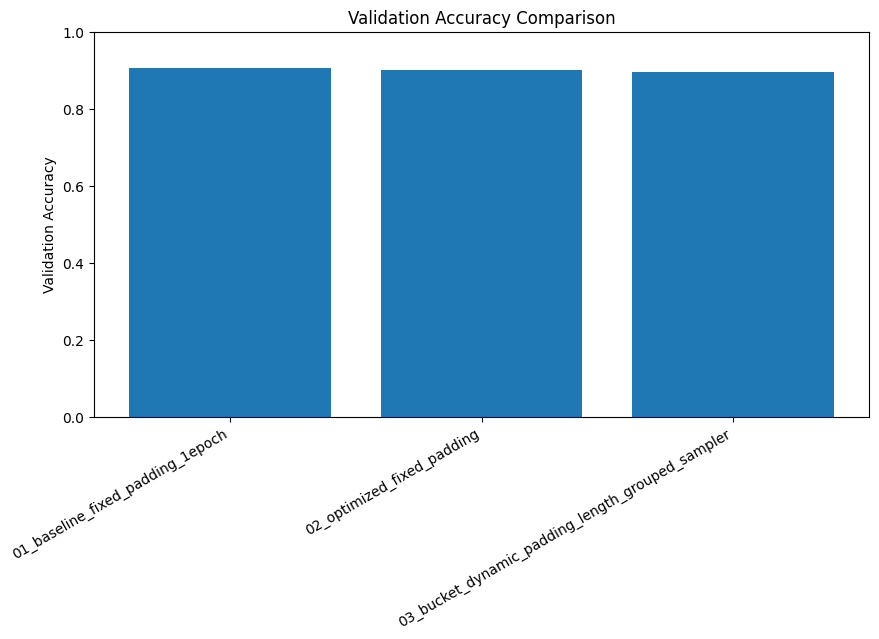

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results["experiment"], results["val_accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

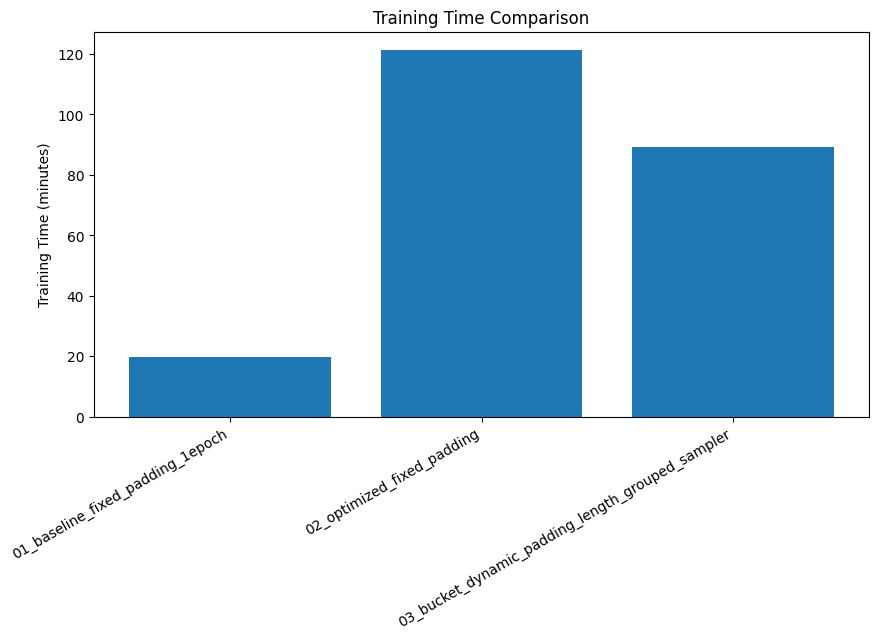

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(results["experiment"], results["train_runtime_min"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")
plt.show()

# STEP 9. 보고서용 분석 문장 자동 생성

아래 셀은 현재 실험 결과를 바탕으로 보고서에 붙여 넣을 수 있는 문장을 출력합니다.

In [1]:
def pct(x):
    return f"{x:.2f}%"

base = comparison.loc[comparison["experiment"] == "01_baseline_fixed_padding_1epoch"].iloc[0]
opt = comparison.loc[comparison["experiment"] == "02_optimized_fixed_padding"].iloc[0]
buck = comparison.loc[comparison["experiment"] == "03_bucket_dynamic_padding_length_grouped_sampler"].iloc[0]

report_text = f'''
[실험 결과 분석]

NSMC 감성분석 데이터셋을 대상으로 과제에서 요구한 klue/bert-base 모델을 fine-tuning하였다.
먼저 baseline 실험에서는 fixed padding(max_length={MAX_LENGTH})과 1 epoch 학습을 적용하여 기준 성능을 확인하였다.
Baseline의 validation accuracy는 {base["val_accuracy"]:.4f}, validation F1은 {base["val_f1"]:.4f}, validation loss는 {base["val_loss"]:.4f}로 나타났다.

이후 성능 개선 실험에서는 최대 epoch를 8로 넉넉하게 설정하고, 매 epoch마다 validation loss를 확인하였다.
또한 load_best_model_at_end=True를 적용하여 validation loss가 가장 낮은 epoch의 모델을 저장하였고,
EarlyStoppingCallback을 사용하여 validation loss가 2회 연속 개선되지 않을 경우 학습을 조기 종료하도록 하였다.
학습 안정화를 위해 warmup_ratio=0.1, cosine learning rate scheduler, AdamW optimizer, max_grad_norm=1.0 gradient clipping을 적용하였다.

개선 실험 결과 validation accuracy는 {opt["val_accuracy"]:.4f}, validation F1은 {opt["val_f1"]:.4f}, validation loss는 {opt["val_loss"]:.4f}를 기록하였다.
Baseline 대비 validation accuracy는 {opt["val_accuracy_diff_vs_baseline"]:.4f}p, 즉 {opt["val_accuracy_improvement_pct_vs_baseline"]:.2f}% 변화하였다.
Validation F1은 {opt["val_f1_diff_vs_baseline"]:.4f}p 변화하였고, validation loss는 {opt["val_loss_reduction_pct_vs_baseline"]:.2f}% 감소하였다.
이를 통해 단순 1 epoch 학습보다 validation 기반 best model 저장, learning rate scheduler, early stopping을 적용한 fine-tuning이 더 안정적인 성능 개선에 도움이 됨을 확인하였다.

마지막으로 Bucketing과 Dynamic Padding을 적용하였다.
기존 fixed padding 방식은 모든 문장을 동일한 길이로 맞추기 때문에 짧은 문장에도 많은 padding token이 추가될 수 있다.
반면 Bucketing 실험에서는 tokenize 단계에서 padding='max_length'를 제거하고, DataCollatorWithPadding을 사용하여 batch 단위 dynamic padding을 적용하였다.
또한 group_by_length=True를 설정하여 길이가 비슷한 문장끼리 batch를 구성하도록 하였다.

Bucketing 적용 결과 validation accuracy는 {buck["val_accuracy"]:.4f}, validation F1은 {buck["val_f1"]:.4f}, validation loss는 {buck["val_loss"]:.4f}로 나타났다.
Optimized fixed padding 방식과 비교했을 때 Bucketing의 accuracy 차이는 {bucket_compare["val_accuracy_diff"].iloc[0]:.4f}p, F1 차이는 {bucket_compare["val_f1_diff"].iloc[0]:.4f}p였다.
학습 시간은 fixed padding {bucket_compare["time_fixed_sec"].iloc[0]:.2f}초, bucketing {bucket_compare["time_bucket_sec"].iloc[0]:.2f}초로 측정되었으며,
Bucketing 적용에 따른 시간 변화율은 {bucket_compare["time_change_pct"].iloc[0]:.2f}%였다.

결론적으로 Bucketing과 Dynamic Padding은 모델 구조를 직접 바꾸는 방법이 아니므로 accuracy가 반드시 크게 향상되는 것은 아니다.
그러나 batch 내부의 불필요한 padding 연산을 줄일 수 있기 때문에 학습 속도와 메모리 효율 측면에서 장점이 있다.
따라서 본 과제에서는 fine-tuning 설정 개선을 통해 모델 성능을 높이고, Bucketing을 통해 학습 효율 개선 가능성을 확인하였다.
'''

print(report_text)

NameError: name 'comparison' is not defined

# 선택 실험. 추가 한국어 모델 비교

NSMC처럼 리뷰/댓글체가 많은 데이터에는 `beomi/KcELECTRA-base`도 비교해볼 수 있다고 하여 실험

In [ ]:
EXTRA_MODEL_NAME = "beomi/KcELECTRA-base"
extra_tokenizer = AutoTokenizer.from_pretrained(EXTRA_MODEL_NAME)

def tokenize_extra(batch):
    return extra_tokenizer(
        batch["document"],
        truncation=True,
        max_length=MAX_LENGTH
    )

extra_dataset = hf_dataset.map(tokenize_extra, batched=True)
extra_dataset = extra_dataset.remove_columns(["document"])
extra_dataset.set_format("torch")

extra_collator = DataCollatorWithPadding(tokenizer=extra_tokenizer)

extra_model = AutoModelForSequenceClassification.from_pretrained(
    EXTRA_MODEL_NAME,
    num_labels=2
)

extra_args = make_training_args(
    output_dir="./result_04_extra_kcelectra",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=5,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_torch",
    max_grad_norm=1.0,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    weight_decay=0.01,

    # GPU 메모리 절약: 실제 효과 batch size = 4 x 4 = 16
    gradient_accumulation_steps=4,
    fp16=torch.cuda.is_available(),
    group_by_length=True,
    save_total_limit=2,
    logging_strategy="epoch",
    report_to="none",
    seed=42
)

extra_trainer = Trainer(
    model=extra_model,
    args=extra_args,
    train_dataset=extra_dataset["train"],
    eval_dataset=extra_dataset["validation"],
    # tokenizer=extra_tokenizer, # Removed as per user request
    data_collator=extra_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0
        )
    ]
)

start_time = time.time()
extra_trainer.train()
extra_time = time.time() - start_time

extra_val = extra_trainer.evaluate(extra_dataset["validation"])
extra_test = extra_trainer.evaluate(extra_dataset["test"])

print("Extra model:", EXTRA_MODEL_NAME)
print("Validation:", extra_val)
print("Test:", extra_test)
print("Training time:", extra_time)

config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Map:   0%|          | 0/131563 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.280221,0.249905,0.906081,0.907261


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# 아쉽게 GPU 사용량이 끝나버려 추가 실험은 끝내지 못하였다. ㅋㅋ
